In [29]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Définir le style de Seaborn
sns.set_style("whitegrid")
sns.set_palette("pastel")

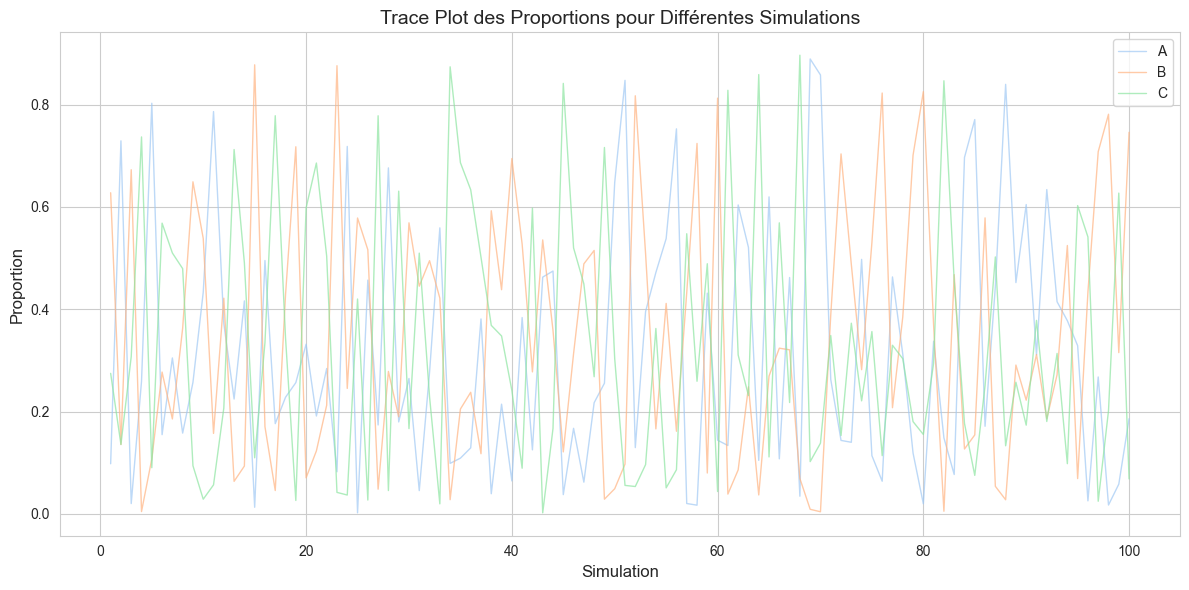

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Définir le style de Seaborn
sns.set_style("whitegrid")
sns.set_palette("pastel")

# Nombre de simulations et de catégories
num_simulations = 100
categories = ['A', 'B', 'C']
num_categories = len(categories)

# Génération de données simulées
np.random.seed(42)  # Pour la reproductibilité
data = []
for sim in range(num_simulations):
    # Générer des proportions aléatoires pour chaque catégorie (la somme doit être 1)
    props = np.random.dirichlet(np.ones(num_categories), size=1)[0]
    for cat_idx, cat in enumerate(categories):
        data.append({
            'Simulation': sim + 1,
            'Category': cat,
            'Proportion': props[cat_idx]
        })

# Création d'un DataFrame
df = pd.DataFrame(data)

# Trace Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Simulation', y='Proportion', hue='Category', lw=1, alpha=0.7)
plt.legend(loc='upper right')
plt.xlabel('Simulation', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.title('Trace Plot des Proportions pour Différentes Simulations', fontsize=14)
plt.tight_layout()
plt.show()



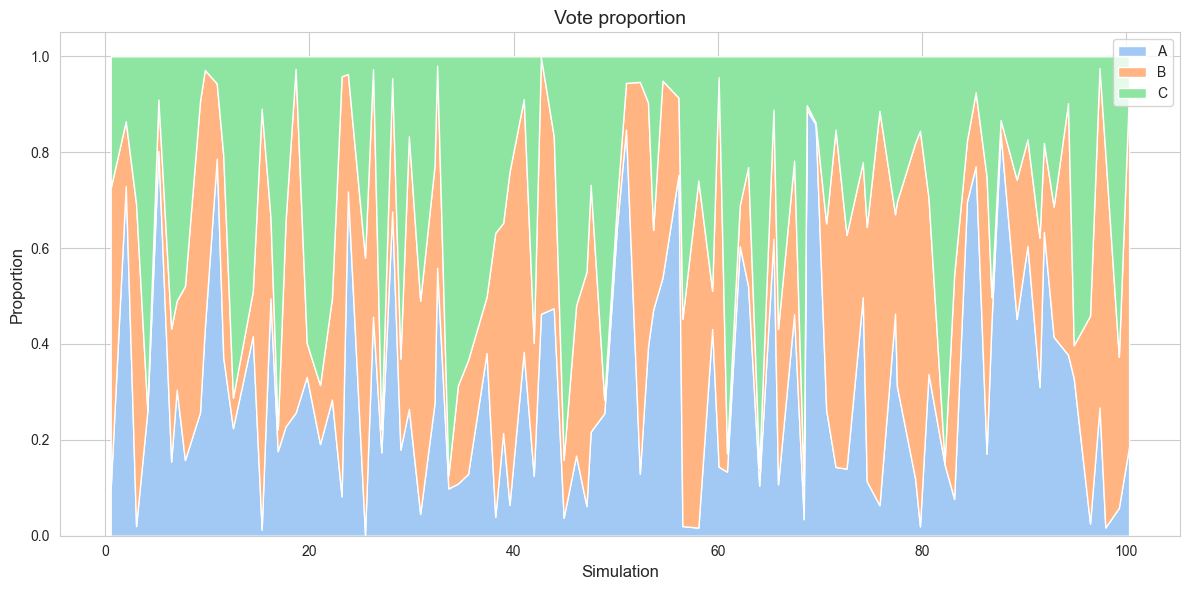

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Définir le style de Seaborn
sns.set_style("whitegrid")
sns.set_palette("pastel")

# Nombre de simulations et de catégories
num_simulations = 100
categories = ['A', 'B', 'C']
num_categories = len(categories)

# Génération de données simulées
np.random.seed(42)  # Pour la reproductibilité
data = []
for sim in range(num_simulations):
    props = np.random.dirichlet(np.ones(num_categories), size=1)[0]
    for cat_idx, cat in enumerate(categories):
        data.append({
            'Simulation': sim + 1,
            'Category': cat,
            'Proportion': props[cat_idx]
        })

df = pd.DataFrame(data)

# Réorganiser les données pour le graphique de zones empilées
simulation_indices = df['Simulation'].unique()
category_proportions = {cat: [] for cat in categories}

for sim in simulation_indices:
    sim_data = df[df['Simulation'] == sim]
    for cat in categories:
        prop = sim_data[sim_data['Category'] == cat]['Proportion'].values
        if len(prop) > 0:
            category_proportions[cat].append(prop[0])
        else:
            category_proportions[cat].append(0)

x = np.arange(1, num_simulations + 1)
y_A = np.array(category_proportions['A'])
y_B = np.array(category_proportions['B'])
y_C = np.array(category_proportions['C'])

noise = np.random.uniform(-0.5, 0.5, size=num_simulations)
x_randomized = x + noise
sorted_indices = np.argsort(x_randomized)
x_sorted = x_randomized[sorted_indices]
y_A_sorted = y_A[sorted_indices]
y_B_sorted = y_B[sorted_indices]
y_C_sorted = y_C[sorted_indices]

plt.figure(figsize=(12, 6))
plt.stackplot(x_sorted, y_A_sorted, y_B_sorted, y_C_sorted,
              labels=categories,
              colors=sns.color_palette("pastel", n_colors=num_categories))
plt.legend(loc='upper right')
plt.xlabel('Simulation', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.title('Vote proportion', fontsize=14)
plt.tight_layout()
plt.show()


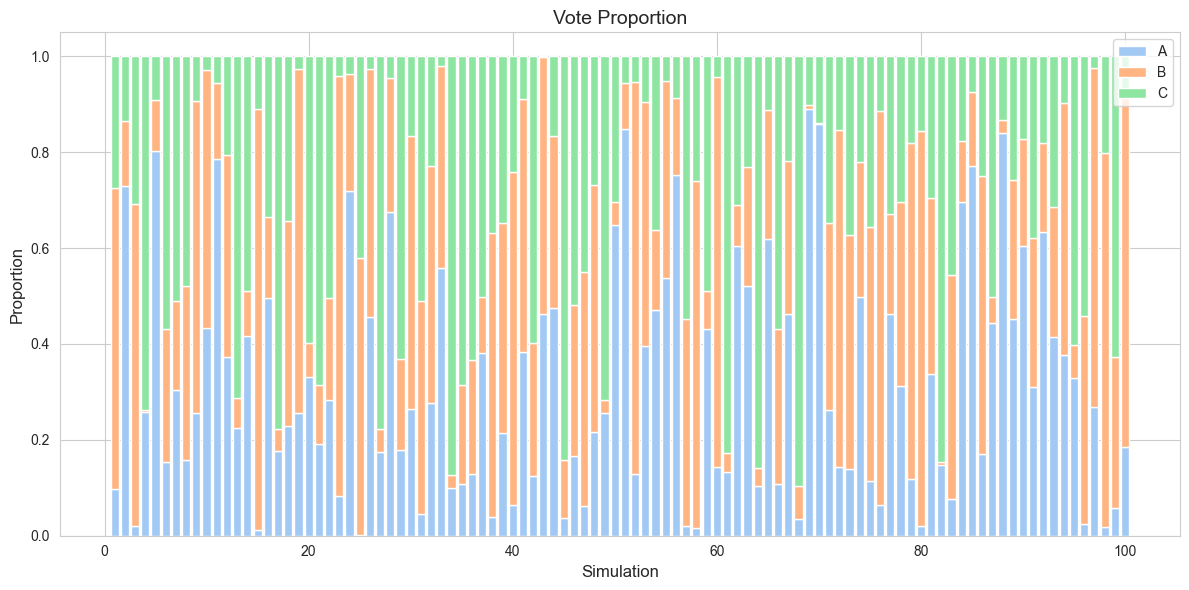

In [25]:
df_pivot = df.pivot(index='Simulation', columns='Category', values='Proportion')
df_pivot = df_pivot.reset_index()

plt.figure(figsize=(12, 6))
bottom = np.zeros(num_simulations)
for cat in categories:
    plt.bar(df_pivot['Simulation'], df_pivot[cat], bottom=bottom, label=cat)
    bottom += df_pivot[cat]

plt.legend(loc='upper right')
plt.xlabel('Simulation', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.title('Vote Proportion', fontsize=14)
plt.tight_layout()
plt.show()


/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_66856/647631178.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df, x='Simulation', y='Proportion', hue='Category', ci='sd', palette='pastel', lw=1, alpha=0.7)


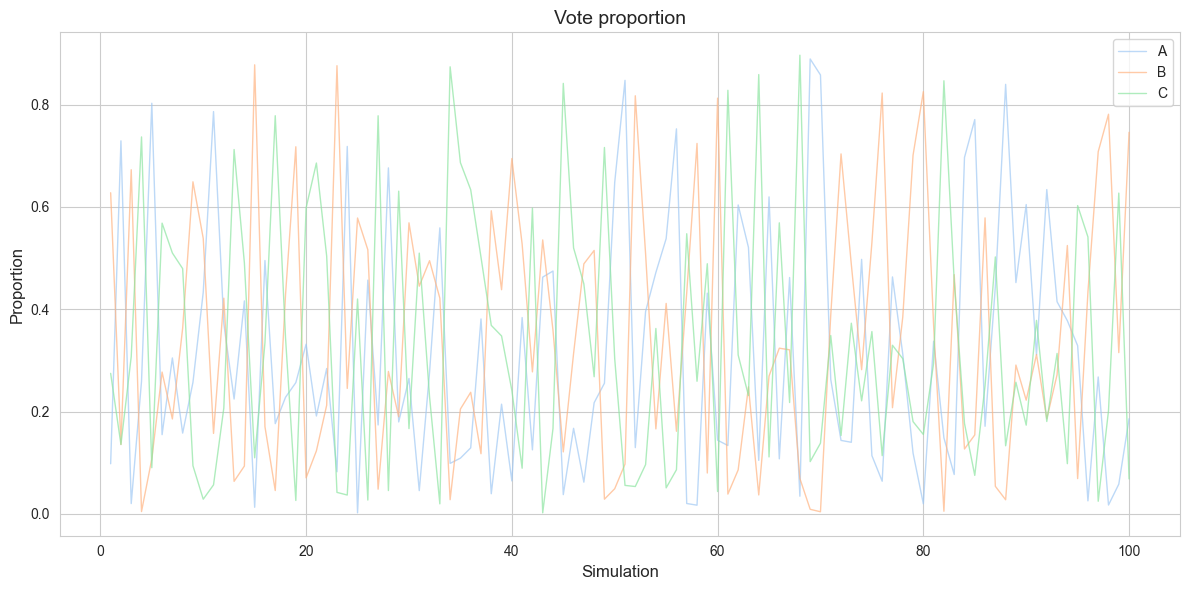

In [27]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Simulation', y='Proportion', hue='Category', ci='sd', palette='pastel', lw=1, alpha=0.7)
plt.legend(loc='upper right')
plt.xlabel('Simulation', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.title('Vote proportion', fontsize=14)
plt.tight_layout()
plt.show()


/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_57206/3336189524.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(beta_distribution(x, alpha, beta), x)


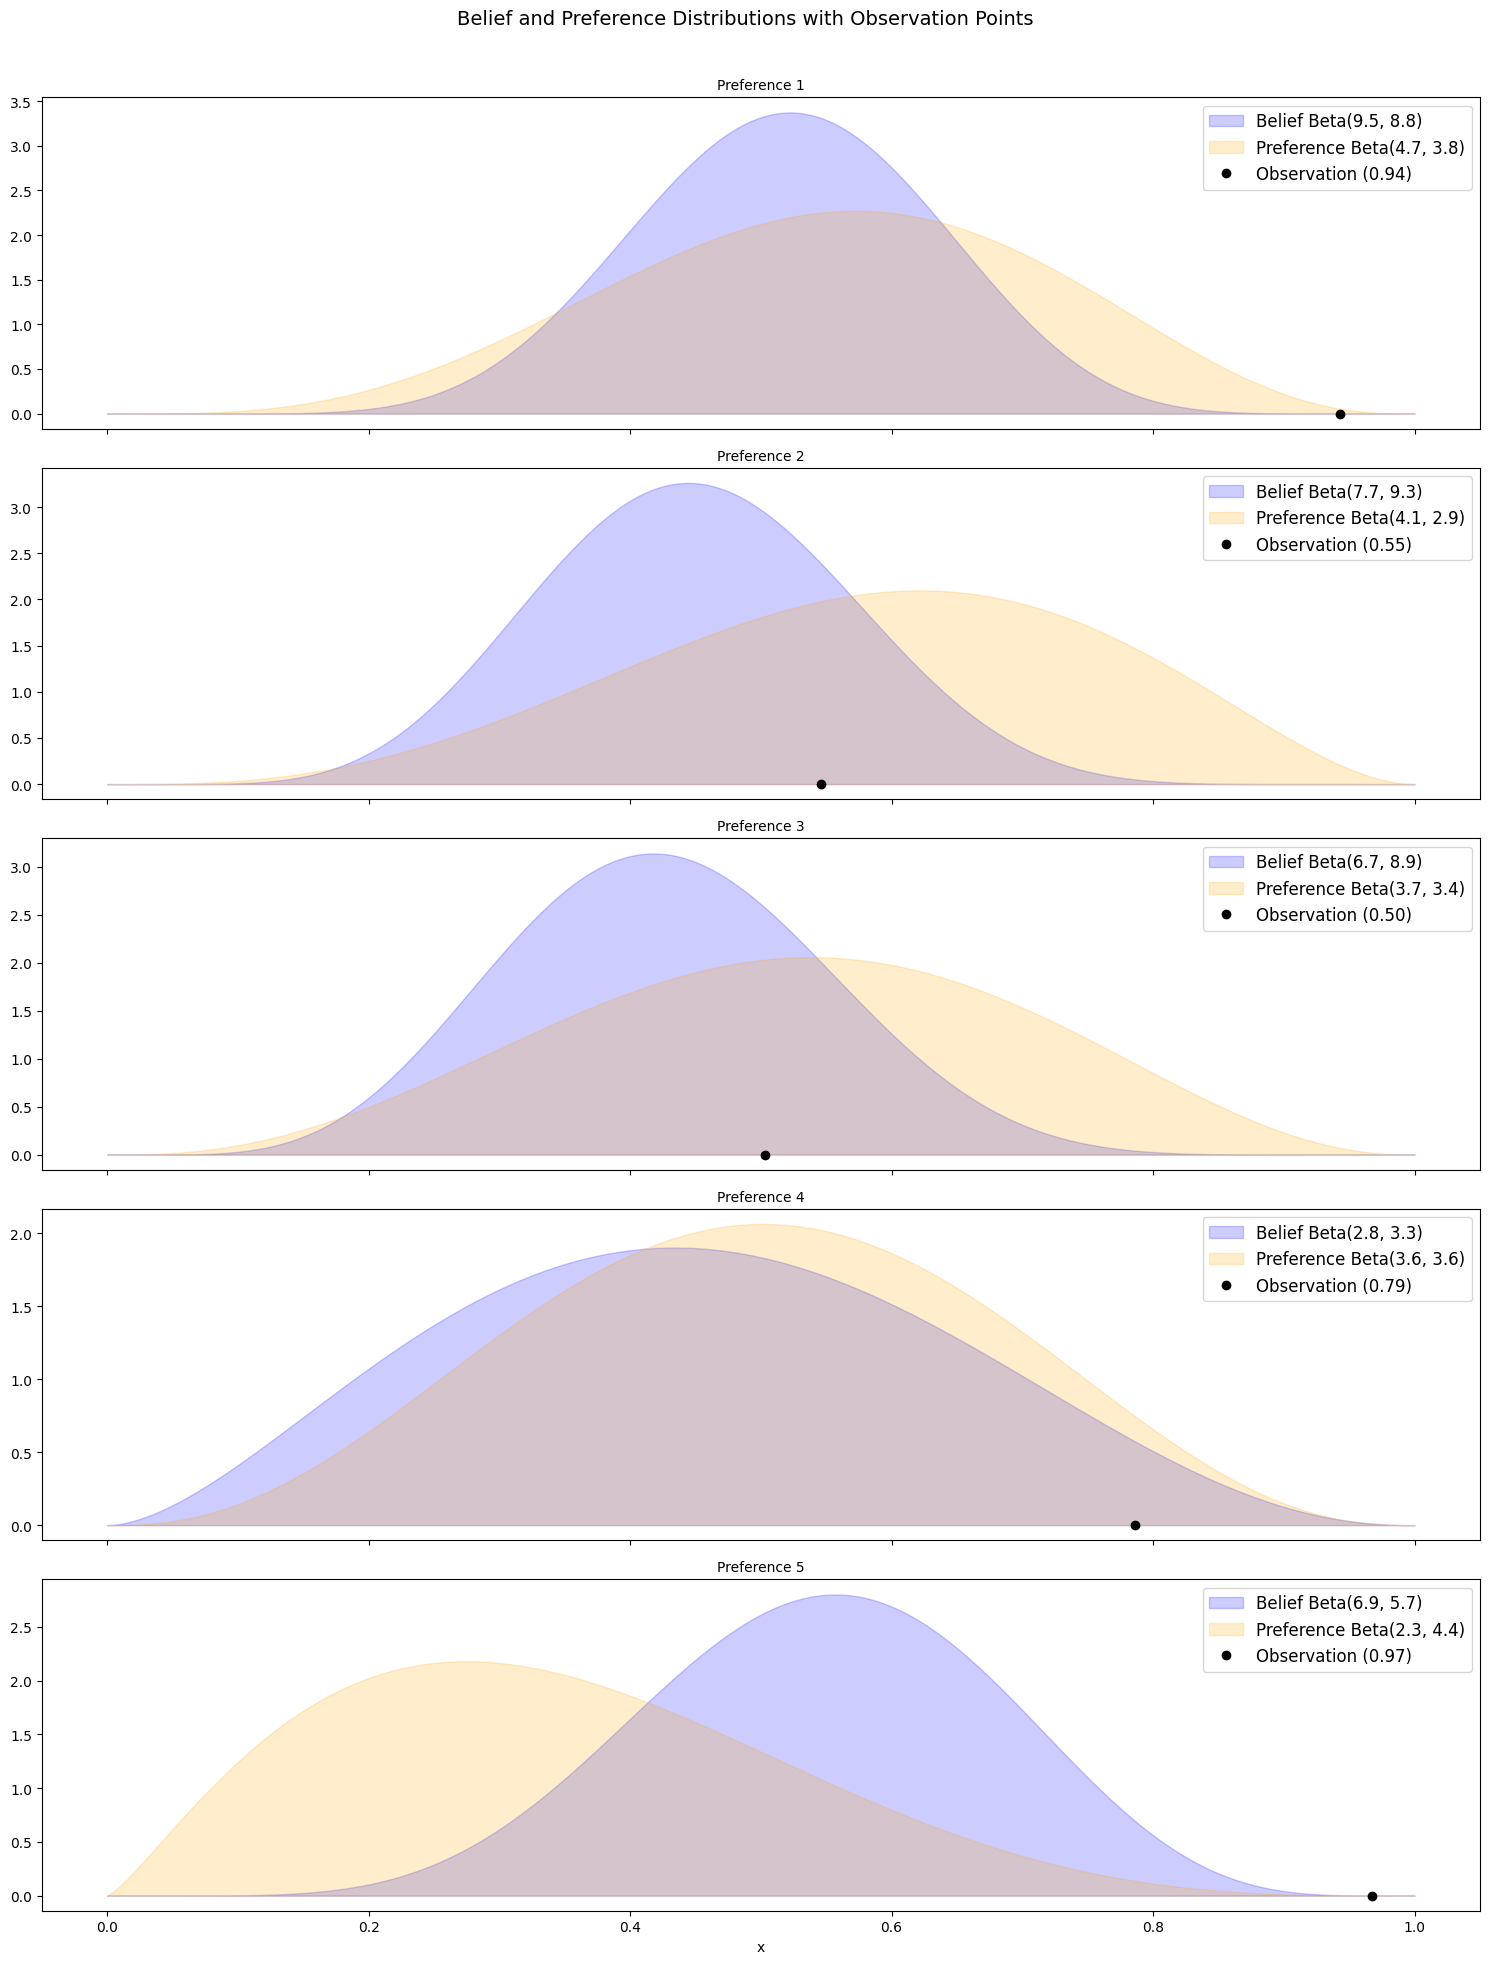

In [2]:
# Define and normalize beta distribution
def beta_distribution(x, alpha, beta):
    return (x ** (alpha - 1)) * ((1 - x) ** (beta - 1))

def normalize_distribution(x, alpha, beta):
    norm = np.trapz(beta_distribution(x, alpha, beta), x)
    return beta_distribution(x, alpha, beta) / norm

# Parameters
x = np.linspace(0, 1, 200)
n_subplots = 5
alphas_belief = np.random.uniform(2, 10, size=n_subplots)
betas_belief = np.random.uniform(2, 10, size=n_subplots)
alphas_pref = np.random.uniform(1, 5, size=n_subplots)
betas_pref = np.random.uniform(1, 5, size=n_subplots)
observations = np.random.uniform(0, 1, size=n_subplots)

# Plot
fig_height = n_subplots * 4
fig, axs = plt.subplots(n_subplots, 1, figsize=(15, fig_height), sharex=True)

for i in range(n_subplots):
    belief = normalize_distribution(x, alphas_belief[i], betas_belief[i])
    pref = normalize_distribution(x, alphas_pref[i], betas_pref[i])
    obs = observations[i]

    axs[i].fill_between(x, belief, alpha=0.2, color='blue',
                        label=f'Belief Beta({alphas_belief[i]:.1f}, {betas_belief[i]:.1f})')
    
    axs[i].fill_between(x, pref, alpha=0.2, color='orange',
                        label=f'Preference Beta({alphas_pref[i]:.1f}, {betas_pref[i]:.1f})')

    axs[i].plot(obs, 0, 'ko', label=f'Observation ({obs:.2f})')

    axs[i].legend(fontsize=12)
    axs[i].set_title(f'Preference {i+1}', fontsize=10)
    axs[i].grid(False)
    fig.suptitle('Belief and Preference Distributions with Observation Points', fontsize=14)
plt.xlabel('x')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

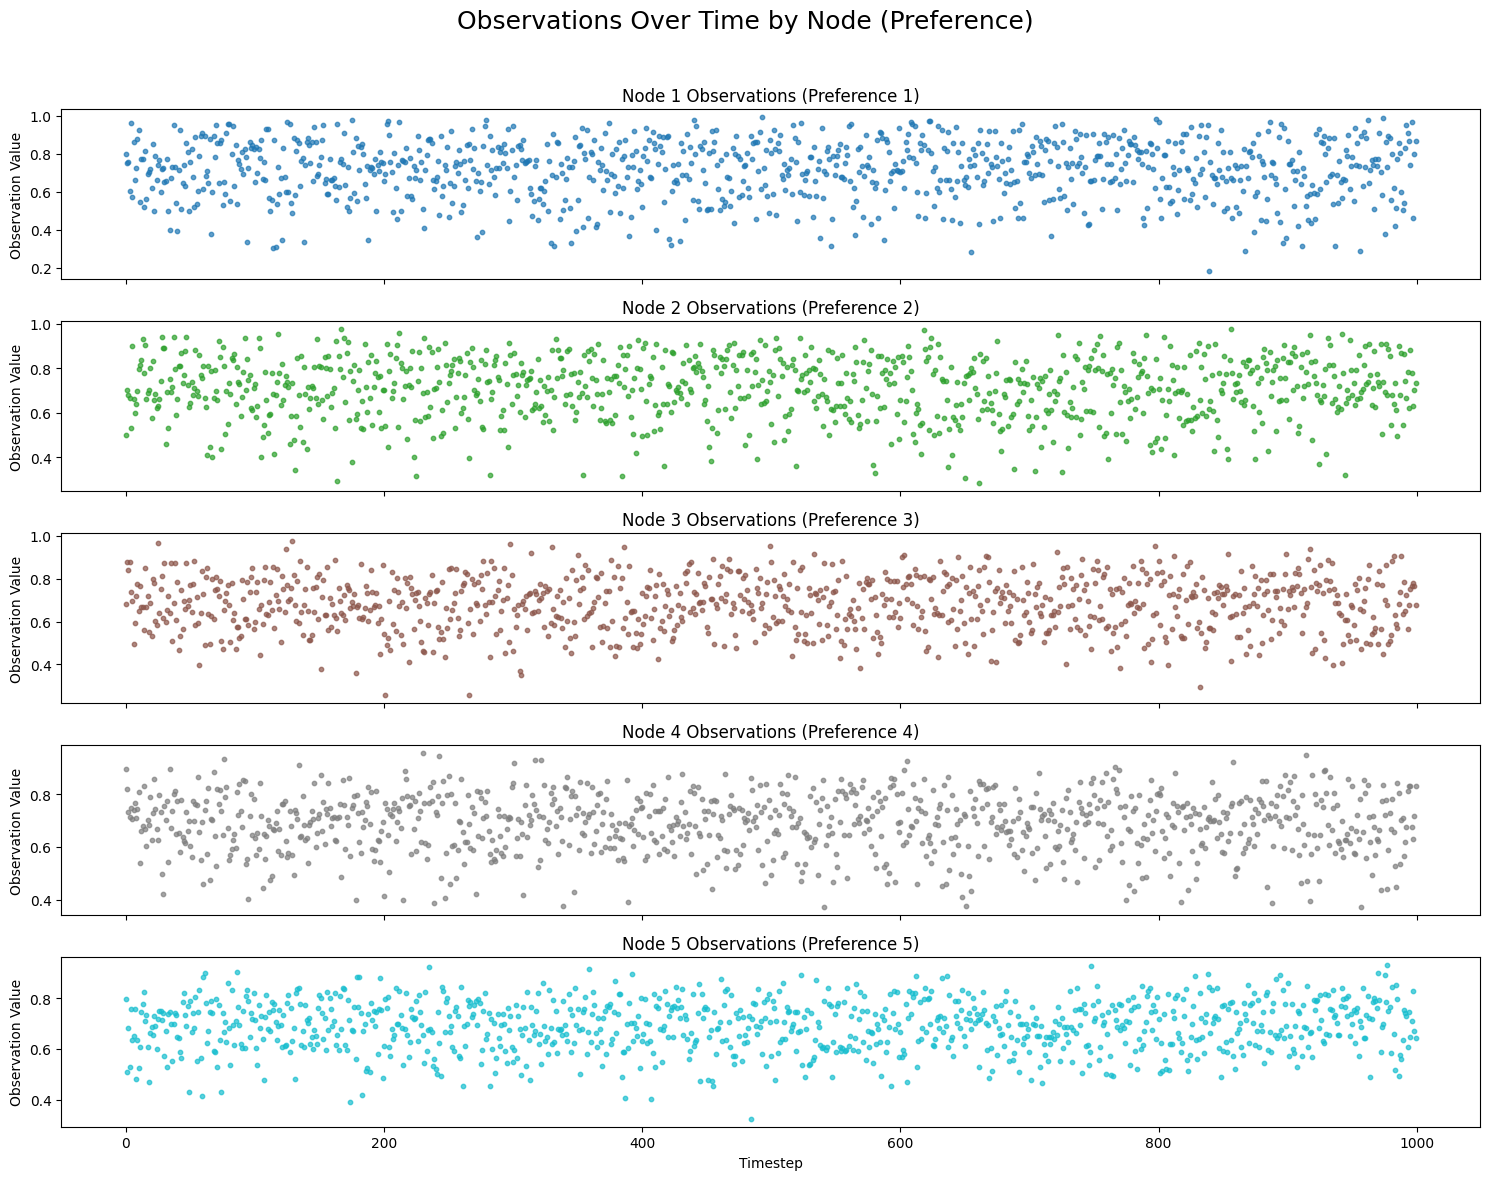

In [3]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

time_steps = np.arange(1000)
n_nodes = 5

obs_nodes = [np.random.beta(a=5 + i*2, b=2 + i, size=1000) for i in range(n_nodes)]

fig, axs = plt.subplots(n_nodes, 1, figsize=(15, 12), sharex=True)

colors = plt.cm.tab10(np.linspace(0, 1, n_nodes))

for i in range(n_nodes):
    axs[i].scatter(time_steps, obs_nodes[i], s=10, alpha=0.7, color=colors[i])
    axs[i].set_title(f"Node {i+1} Observations (Preference {i+1})")
    axs[i].set_ylabel("Observation Value")

axs[-1].set_xlabel("Timestep")
fig.suptitle("Observations Over Time by Node (Preference)", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()